<a href="https://colab.research.google.com/github/MITHILESH0708/portfolio/blob/main/student_social_media_usage_%26_mental_health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Dataset
                        Timestamp What is your current academic year?   \
0  2026/08/19 6:38:33 PM GMT+5:30                             3rd year   
1  2026/08/19 6:42:35 PM GMT+5:30                             2nd year   
2  2026/08/19 6:46:23 PM GMT+5:30                             2nd year   
3  2026/08/19 6:54:34 PM GMT+5:30                             2nd year   
4  2026/08/19 7:08:06 PM GMT+5:30                             2nd year   

    What is your major/department?    \
0                                cse   
1                CSE(Cyber Security)   
2                     Cybersecurity    
3                    Cyber security    
4                                ECE   

     3. On average, how many hours per week do you spend studying outside of class?  \
0                                                 15                                  
1                                                  3                                  
2                                   

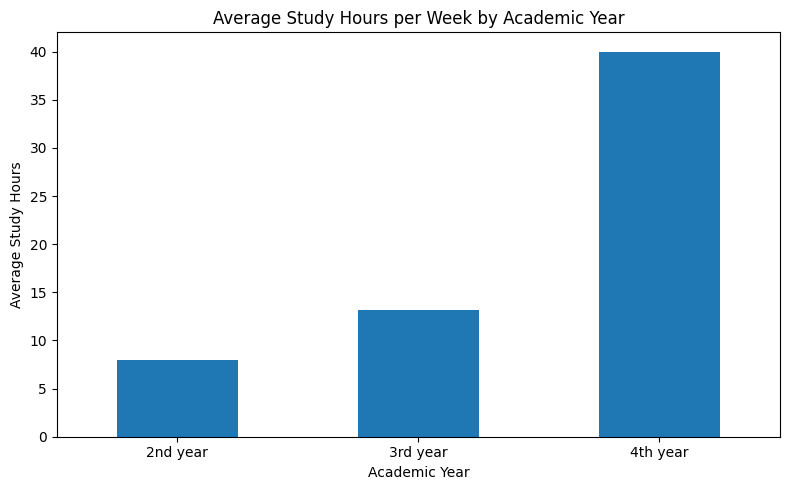

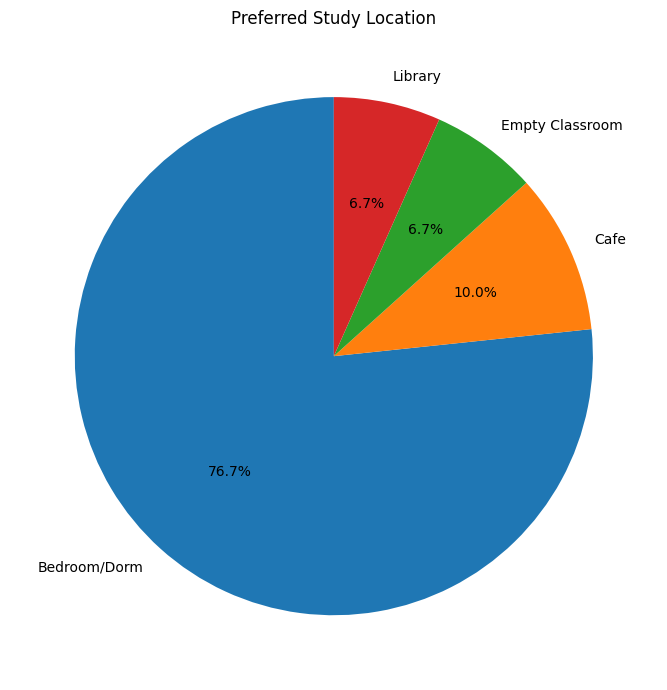

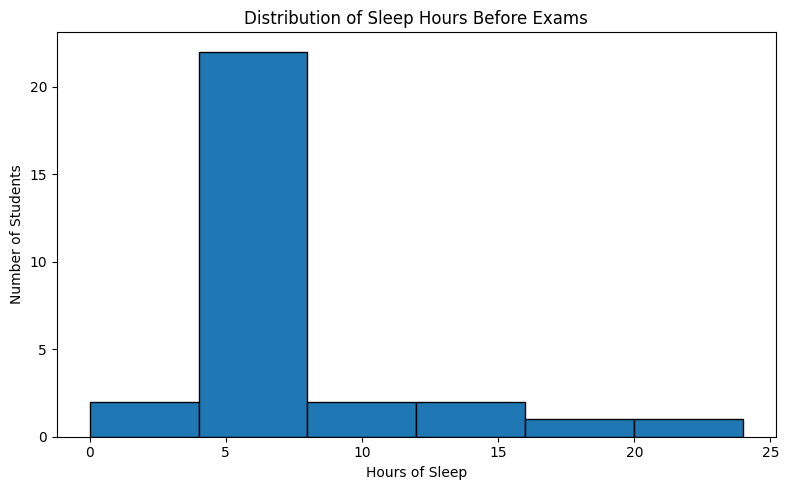


========== ADDITIONAL INSIGHTS ==========
Average study hours: 13.6
Average sleep hours: 7.0
Average stress level: 3.23
Average procrastination level: 3.23

========== CORRELATION ANALYSIS ==========
                                                    3. On average, how many hours per week do you spend studying outside of class?  \
3. On average, how many hours per week do you s...                                           1.000000                                
4. How many hours of sleep do you usually get t...                                          -0.053891                                
12. On a scale of 1-5, how stressed do you feel...                                          -0.059898                                
13. On a scale of 1-5, how often do you procras...                                           0.138893                                

                                                    4. How many hours of sleep do you usually get the night before an exam?  \
3

/tmp/ipykernel_5166/3621374988.py:249: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


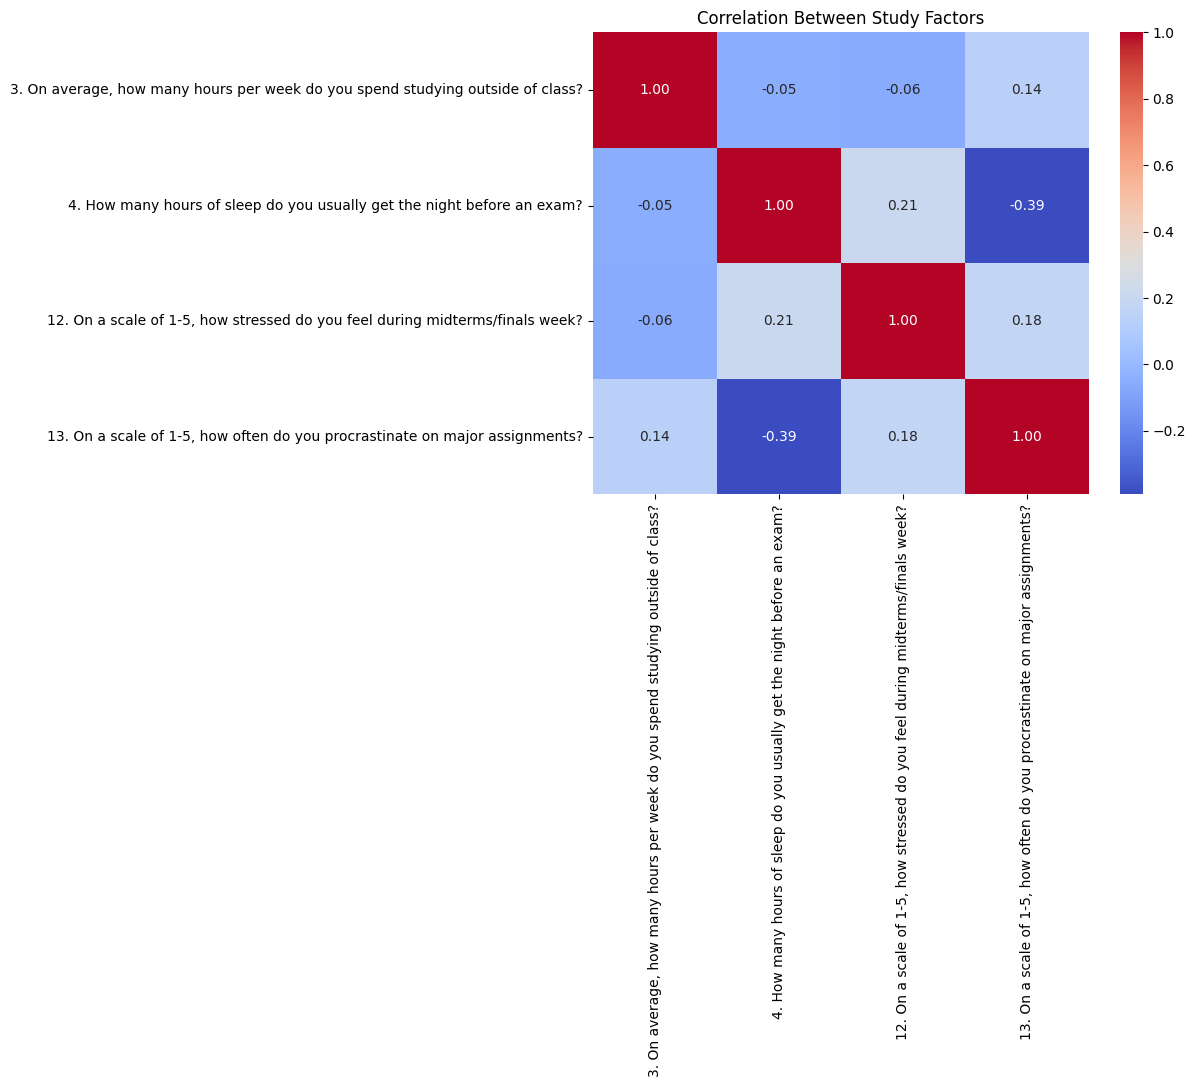


DATA ANALYSIS COMPLETED
Files generated:
1. cleaned_students.csv
2. statistical_analysis.csv
3. bar_chart.png
4. pie_chart.png
5. histogram.png
6. correlation_heatmap.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------
# 1. LOAD DATASET
# -----------------------------------

df = pd.read_csv("students.csv")

print("Original Dataset")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

# -----------------------------------
# 2. CLEAN COLUMN NAMES
# -----------------------------------

df.columns = df.columns.str.strip()

print("\nColumn Names:")
for i, col in enumerate(df.columns):
    print(i, col)

# -----------------------------------
# 3. CHECK MISSING VALUES
# -----------------------------------

print("\nMissing Values:")
print(df.isnull().sum())

# Remove completely empty rows
df.dropna(how="all", inplace=True)

# -----------------------------------
# 4. REMOVE DUPLICATES
# -----------------------------------

duplicates = df.duplicated().sum()

print("\nDuplicate Rows:", duplicates)

df.drop_duplicates(inplace=True)

print("Rows after cleaning:", len(df))

# -----------------------------------
# 5. CONVERT NUMERICAL COLUMNS
# -----------------------------------

numeric_columns = [
    "3. On average, how many hours per week do you spend studying outside of class?",
    "4. How many hours of sleep do you usually get the night before an exam?",
    "5. How many lectures or classes do you skip in a typical month?",
    "6. What is your current GPA or overall percentage?",
    "11. On a scale of 1-5, how would you rate your personal time management skills?",
    "12. On a scale of 1-5, how stressed do you feel during midterms/finals week?",
    "13. On a scale of 1-5, how often do you procrastinate on major assignments?",
    "14. On a scale of 1-5, how confident do you feel about your current study methods?"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# -----------------------------------
# 6. DISPLAY CLEANED DATA
# -----------------------------------

print("\nCleaned Dataset:")
print(df.head())

# -----------------------------------
# 7. STATISTICAL ANALYSIS
# -----------------------------------

print("\n========== STATISTICAL ANALYSIS ==========")

for col in numeric_columns:

    mean = df[col].mean()
    median = df[col].median()
    mode = df[col].mode()

    print("\n", col)
    print("Mean   :", round(mean, 2))
    print("Median :", round(median, 2))

    if not mode.empty:
        print("Mode   :", mode.iloc[0])
    else:
        print("Mode   : No mode")

# -----------------------------------
# 8. SAVE STATISTICS TO CSV
# -----------------------------------

statistics = []

for col in numeric_columns:

    statistics.append({
        "Attribute": col,
        "Mean": round(df[col].mean(), 2),
        "Median": round(df[col].median(), 2),
        "Mode": df[col].mode().iloc[0]
        if not df[col].mode().empty else "No Mode"
    })

stats_df = pd.DataFrame(statistics)

stats_df.to_csv("statistical_analysis.csv", index=False)

print("\nStatistical analysis saved as statistical_analysis.csv")

# -----------------------------------
# 9. BAR CHART
# -----------------------------------

year_col = "What is your current academic year?"

study_col = "3. On average, how many hours per week do you spend studying outside of class?"

year_study = df.groupby(year_col)[study_col].mean()

plt.figure(figsize=(8, 5))

year_study.plot(kind="bar")

plt.title("Average Study Hours per Week by Academic Year")
plt.xlabel("Academic Year")
plt.ylabel("Average Study Hours")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("bar_chart.png")

plt.show()

# -----------------------------------
# 10. PIE CHART
# -----------------------------------

place_col = "7. Where is your primary and most preferred place to study?"

place_counts = df[place_col].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    place_counts,
    labels=place_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Preferred Study Location")

plt.tight_layout()

plt.savefig("pie_chart.png")

plt.show()

# -----------------------------------
# 11. HISTOGRAM
# -----------------------------------

sleep_col = "4. How many hours of sleep do you usually get the night before an exam?"

plt.figure(figsize=(8, 5))

plt.hist(
    df[sleep_col].dropna(),
    bins=6,
    edgecolor="black"
)

plt.title("Distribution of Sleep Hours Before Exams")
plt.xlabel("Hours of Sleep")
plt.ylabel("Number of Students")

plt.tight_layout()

plt.savefig("histogram.png")

plt.show()

# -----------------------------------
# 12. ADDITIONAL ANALYSIS
# -----------------------------------

print("\n========== ADDITIONAL INSIGHTS ==========")

print(
    "Average study hours:",
    round(df[study_col].mean(), 2)
)

print(
    "Average sleep hours:",
    round(df[sleep_col].mean(), 2)
)

stress_col = "12. On a scale of 1-5, how stressed do you feel during midterms/finals week?"

print(
    "Average stress level:",
    round(df[stress_col].mean(), 2)
)

procrastination_col = "13. On a scale of 1-5, how often do you procrastinate on major assignments?"

print(
    "Average procrastination level:",
    round(df[procrastination_col].mean(), 2)
)

# -----------------------------------
# 13. CORRELATION
# -----------------------------------

print("\n========== CORRELATION ANALYSIS ==========")

correlation = df[
    [
        study_col,
        sleep_col,
        stress_col,
        procrastination_col
    ]
].corr()

print(correlation)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Study Factors")

plt.tight_layout()

plt.savefig("correlation_heatmap.png")

plt.show()

# -----------------------------------
# 14. SAVE CLEANED DATA
# -----------------------------------

df.to_csv("cleaned_students.csv", index=False)

print("\n====================================")
print("DATA ANALYSIS COMPLETED")
print("====================================")

print("Files generated:")
print("1. cleaned_students.csv")
print("2. statistical_analysis.csv")
print("3. bar_chart.png")
print("4. pie_chart.png")
print("5. histogram.png")
print("6. correlation_heatmap.png")